<a href="https://colab.research.google.com/github/Kabeer90/Traffic-Sign-Detection-Using-CNN/blob/my_branch/Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

# 1. Set your Kaggle API credentials directly
os.environ['KAGGLE_USERNAME'] = "kabirabubakarka4"
os.environ['KAGGLE_KEY'] = "KGAT_3d2ef6b758d7c216b66afc6a22dee9bc"

# 2. Install Kaggle quietly
!pip install -q kaggle

# 3. Download the Traffic Sign dataset (CORRECTED ID)
!kaggle datasets download -d ahemateja19bec1025/traffic-sign-dataset-classification

# 4. Unzip it into the folder the code expects
!unzip -q traffic-sign-dataset-classification.zip -d traffic_Data


Dataset URL: https://www.kaggle.com/datasets/ahemateja19bec1025/traffic-sign-dataset-classification
License(s): CC0-1.0
 76% 145M/190M [00:00<00:00, 1.51GB/s]
100% 190M/190M [00:00<00:00, 1.13GB/s]


The above code engineered a script to bypass the local machine entirely and pull the data directly from Kaggle's servers to Google's Colab servers using Python's os module and the Kaggle Command Line Interface (CLI).

## Importing Libraries
**Importing the libraries needed to build this program**

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from PIL import Image #used to import the Image module from the Python Imaging Library (PIL),Pillow.
import os
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout
import matplotlib.pyplot as plt
import plotly.express as px
import random

In [3]:
import tensorflow as tf
import numpy as np
import random

# Lock the random seeds for perfect reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

## Setting the folder paths of testing and training data into variables
**Doing this to imnprove code readability**

In [4]:
train_folder='traffic_Data/traffic_Data/DATA' # had to correct the file directories here. it was a pain in the a**
test_folder='traffic_Data/traffic_Data/TEST'
classes=pd.read_csv('traffic_Data/labels.csv')
classSize=len(classes)
print(classSize)

58


## Defining a function to load the images and their respective labels into arrays

This block defines a function to manually crawl through the folders, process the images, and attach the correct labels to them.

In [5]:
# creating empty lists to store the newly mapped datas
traffic_data = []
train_data=[] # this empty list has not been used!
labels = []

def fetch_image(traffic_data, labels):
    for classValue in os.listdir(train_folder):# this loop iterates through the train_folder('traffic_Data/DATA')and iterates over every sub-folder it finds. The name of the sub-folder (which is a number) is temporarily stored as classValue.
        classPath=os.path.join(train_folder,classValue) #  creates a full path to that specific sub-folder
        labels.append(classValue) #adds this folder name to a master list of all the labels.
        for trafficSignal in os.listdir(classPath):# this loop now, then looks inside the current sub-folder and iterates through every single image file in there.
            imgTrafficSignal=Image.open(os.path.join(classPath,trafficSignal))
            imgTrafficSignal = imgTrafficSignal.convert("L")
            imgTrafficSignal = imgTrafficSignal.resize((90,90))
            imgTrafficSignal = np.array(imgTrafficSignal)
            traffic_data.append((imgTrafficSignal,[int(classValue)])) #takes the processed image matrix and packages it together with its label (classValue, converted to an integer) into a Python tuple, and saves it to the traffic_data list.

    labels=np.array(labels)
    return traffic_data,labels

## Spliting the training data into the features and labels respectively for model training
**Further splitting the features and labels into training and validation data (1/3rd of the dataset used for validation)**

In [6]:
traffic_data,labels = fetch_image(traffic_data,labels) # this is where the 'def fetch_image(traffic_data, labels):' in the previous block comes to life
traffic_data_features,traffic_data_labels = zip(*traffic_data) # this seperates the (image,label) format into two distinct tuples
training_data_features,validation_data_features,training_data_labels,validation_data_labels = train_test_split(traffic_data_features, traffic_data_labels, test_size=0.33, random_state=42)
training_data_features = np.array(training_data_features)
training_data_labels = np.array(training_data_labels)
validation_data_features = np.array(validation_data_features)
validation_data_labels = np.array(validation_data_labels)
print(training_data_features.shape)
print(training_data_labels.shape)

(2793, 90, 90)
(2793, 1)


## Defining a neural network using tensorflow and keras
**Using a Convolutional neural network as CNN's are particularly useful for finding patterns in images to recognize objects, classes, and categories**

In [7]:
cnnModel = Sequential()

# first block of convolution to pooling
cnnModel.add(Conv2D(16,(3,3), padding="same", input_shape=(90, 90, 1), activation='relu')) # 16 layers with 3x3 kernel size and a padding.
print(cnnModel(training_data_features).shape)
cnnModel.add(MaxPool2D((2,2), strides=None, padding="same"))

# second block with larger layer(32) because we are implementing a Hierarchical Feature Learning where we gradually increase the numbers of layers.  Adding layers incrementally allows the network to solidify understanding of fundamental features before stacking complex layers, making the learning process more stable.
cnnModel.add(Conv2D(32,(3,3), padding="same", activation='relu'))
cnnModel.add(MaxPool2D((2,2), strides=None, padding="same"))

# third block
cnnModel.add(Conv2D(64,(5,5), padding="same", activation='relu'))
cnnModel.add(MaxPool2D((2,2), strides=None, padding="same"))

# fourth block
cnnModel.add(Conv2D(128,(7,7), padding="same", activation='relu'))
cnnModel.add(MaxPool2D((2,2), strides=None, padding="same"))

cnnModel.add(Flatten()) # unrolls that 3D block into a single long list of 4,608 numbers.
cnnModel.add(Dense(232, activation='relu'))
cnnModel.add(Dense(116, activation='relu'))# this layer takes the flattened features and learn how to combine them to make a final decision.
cnnModel.add(Dense(58, activation='softmax')) # output layer with softmax AF

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


(2793, 90, 90, 16)


In [8]:
cnnModel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 90, 90, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 45, 45, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 23, 23, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 232)            │     1,069,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 116)            │        27,028 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 58)             │         6,786 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,560,702 (5.95 MB)

 Trainable params: 1,560,702 (5.95 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling and fitting the model to the training data

In [9]:
cnnModel.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['accuracy']) # initially it was (from_logits=True), which is wrong because softmax has already been added previously and logits are the raw numbers outputted from a layer before enterin AF, so we are basically reconverting the already converting numbers into prob, which is mathematically wrong and inefficient
trafficSignNetwork = cnnModel.fit(training_data_features, training_data_labels, batch_size=14, epochs=12, validation_data=(validation_data_features, validation_data_labels))

Epoch 1/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.1783 - loss: 6.3428 - val_accuracy: 0.5708 - val_loss: 1.7456
Epoch 2/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7032 - loss: 1.1954 - val_accuracy: 0.7800 - val_loss: 0.8283
Epoch 3/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8472 - loss: 0.5521 - val_accuracy: 0.8134 - val_loss: 0.7911
Epoch 4/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9179 - loss: 0.2894 - val_accuracy: 0.8838 - val_loss: 0.5371
Epoch 5/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9329 - loss: 0.2274 - val_accuracy: 0.9136 - val_loss: 0.3911
Epoch 6/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9682 - loss: 0.1450 - val_accuracy: 0.8656 - val_loss: 0.7068
Epoch 7/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9582 - loss: 0.1316 - val_accuracy: 0.9107 - val_loss: 0.5026
Epoch 8/12
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9650 - loss: 0.1428 - val_accuracy: 

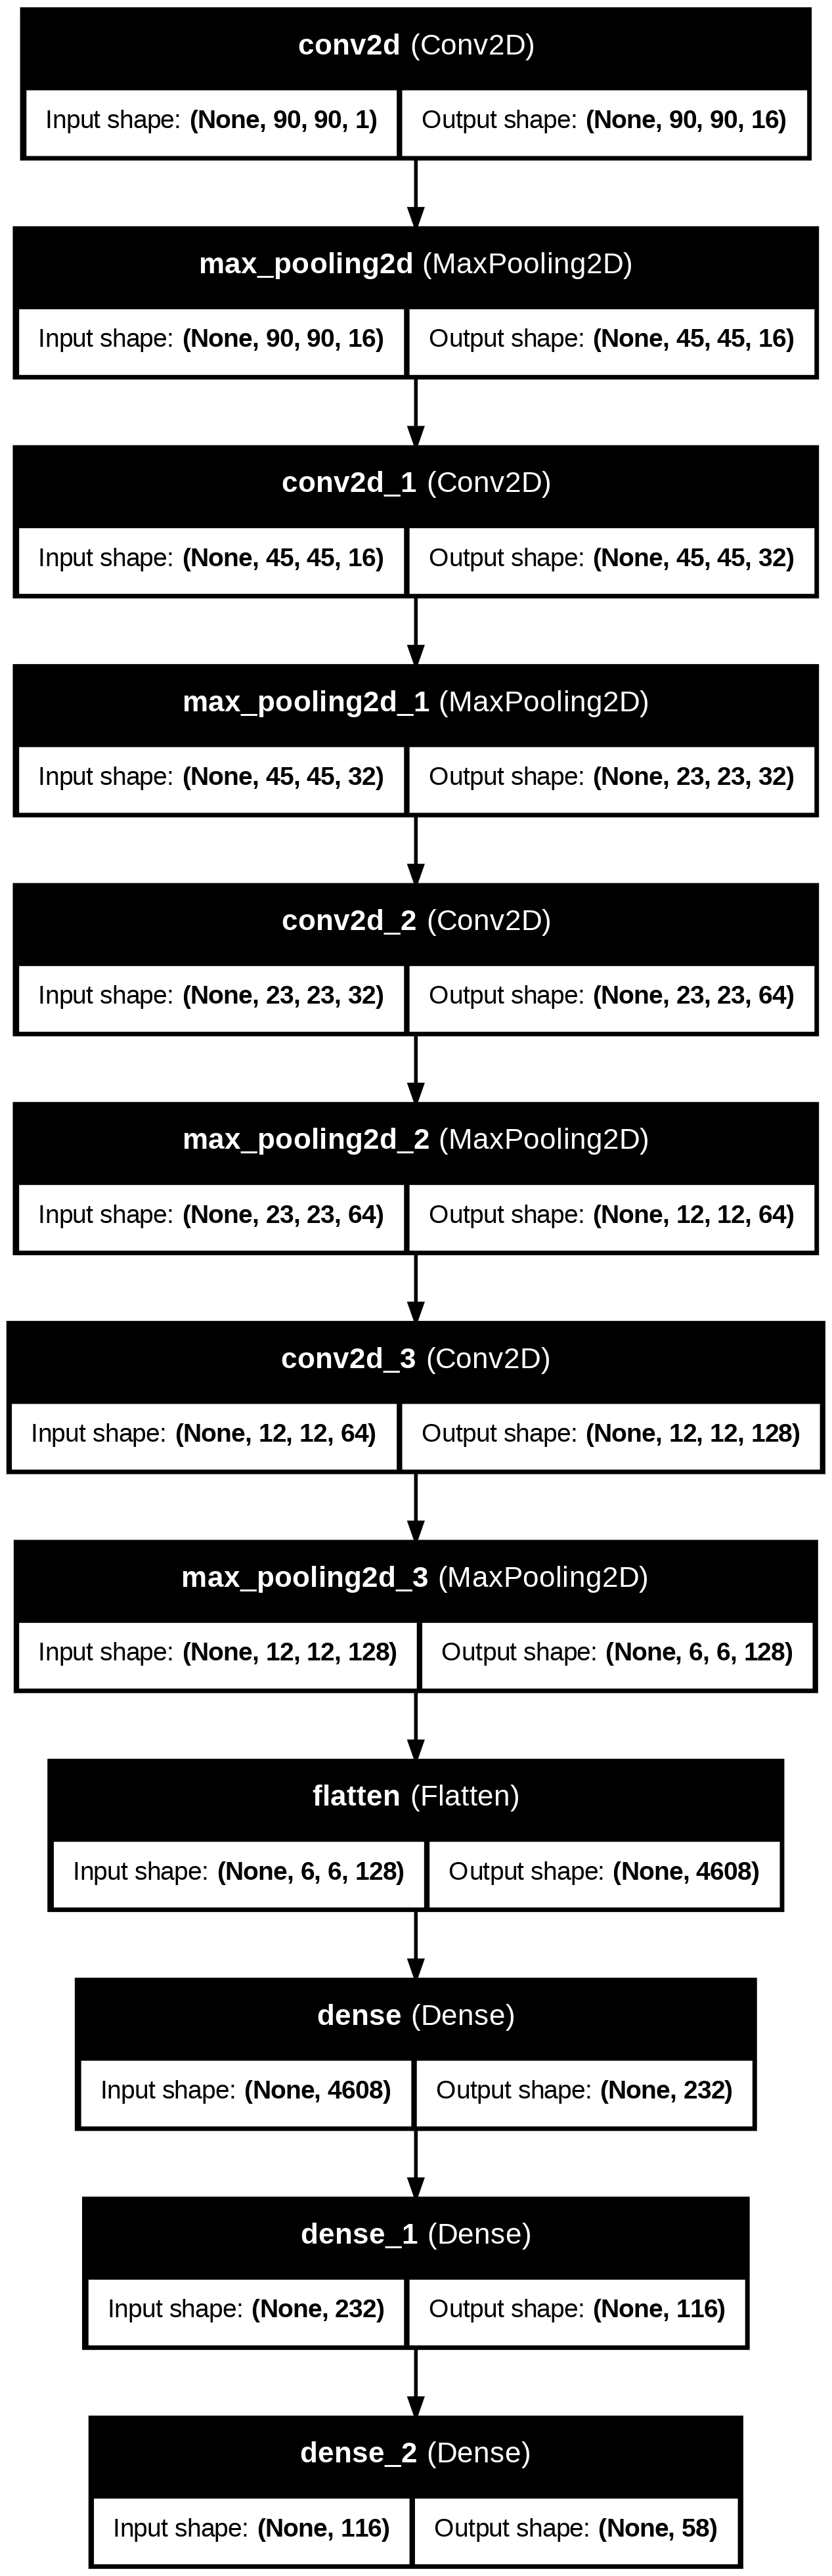

In [10]:
from keras.utils import plot_model

# This will generate and display a high-quality PNG image of your network
plot_model(cnnModel, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

## Graphical Representation of the accuracy of the model over the epochs

In [11]:
import seaborn as sns

<Axes: >

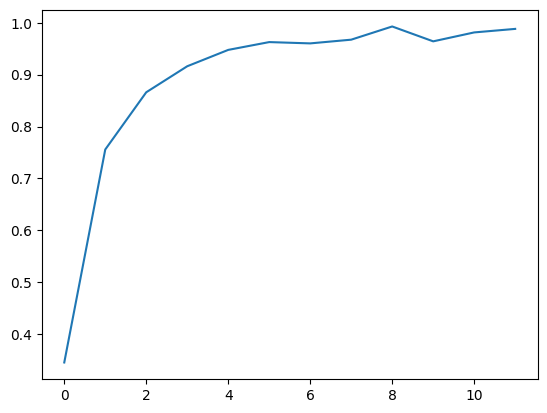

In [12]:
sns.lineplot(trafficSignNetwork.history['accuracy'])

## Testing the model on unseen data

In [13]:
test_data=[]
for test_image_file in os.listdir(test_folder):
    testImage=Image.open(os.path.join(test_folder,test_image_file))
    testImage=testImage.convert('L')
    testImage=testImage.resize((90,90))
    testImage=np.array(testImage)
    test_data.append((testImage,[int(test_image_file[1:3])]))

test_data_features, test_data_labels= zip(*test_data)
test_data_features=np.array(test_data_features)
test_data_labels=np.array(test_data_labels)

In [14]:
predictions=cnnModel.predict(test_data_features)
predictions

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


array([[1.1540630e-28, 1.2984278e-30, 8.1460501e-32, ..., 1.6912579e-34,
        6.0423572e-29, 5.7798854e-36],
       [3.0847374e-07, 2.4272725e-07, 1.8813229e-05, ..., 2.1966318e-05,
        1.7417169e-05, 3.5332980e-07],
       [1.1997602e-15, 1.7231915e-08, 3.6998414e-02, ..., 3.2919067e-24,
        1.4190603e-23, 1.8177235e-21],
       ...,
       [1.2172946e-07, 1.5026419e-13, 1.2980907e-10, ..., 2.2629611e-02,
        4.7937117e-20, 1.0732516e-34],
       [6.0428184e-04, 9.9232906e-09, 7.0091558e-12, ..., 1.4041618e-12,
        2.5042528e-13, 1.1845557e-16],
       [2.8125903e-06, 4.8560207e-07, 2.2508453e-11, ..., 3.5109696e-10,
        4.1811796e-07, 1.2888836e-11]], dtype=float32)

In [15]:
predicted_labels=np.argmax(predictions, axis=1)

In [16]:
predicted_labels

array([11, 27,  6, ..., 40, 38, 45])

In [17]:
print(classes['Name'][predicted_labels])

11                   Dont Go Left
27           Roundabout mandatory
6            Speed limit (70km/h)
35                 Zebra Crossing
5            Speed limit (60km/h)
                 ...             
11                   Dont Go Left
35                 Zebra Crossing
40                       Unknown1
38    Dangerous curve to the left
45                       Unknown4
Name: Name, Length: 1994, dtype: object


In [18]:
print(classes['Name'][test_data_labels[:,0]])

11                    Dont Go Left
31                           Uturn
6             Speed limit (70km/h)
31                           Uturn
3             Speed limit (40km/h)
                  ...             
11                    Dont Go Left
24                        Go Right
23                Go Left or right
43            Go right or straight
39    Dangerous curve to the right
Name: Name, Length: 1994, dtype: object


## Saving the model in both .h5 and .keras file formats for use in applications

In [19]:
cnnModel.save("model.h5")

In [20]:
cnnModel.save("model.keras")